In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import os
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [2]:
img_name = '20260717T120225_pA_Activin_D4_48hr_W0001'
channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']
if_cols = [c + '_mean' for c in channel_names if c != 'Hoechst']

out = tiff.imread(f'../data/stitched/{img_name}.tif')
print(out.shape)

(4, 1998, 1998)


### Patch-based (segmentation-free) CNN

`features.ipynb`'s neighbor-IF prediction (`models.gnn`/`models.gat`) depends entirely
on Cellpose's cell segmentation -- every "cell" is a segmented region, and every
"neighbor" is a nearby segmented centroid. If segmentation quality itself is
questionable (missed cells, merged/split nuclei, inconsistent boundaries), a poor
GNN result is ambiguous: is the biology just not there, or is segmentation noise
drowning it out?

This notebook asks the same question -- do NEIGHBORING regions predict a region's
own markers -- without touching Cellpose at all. The image is tiled into a fixed
grid of `PATCH_SIZE`-px patches (`models.cnn.build_patch_data`); each patch's own
mean intensity per channel stands in for a "cell", and its up-to-8 grid-adjacent
patches stand in for "neighbors" (Moore neighborhood, mean-pooled via a shared CNN
encoder instead of a distance-weighted graph conv). Same `x_cols`/`neighbor_cols`/
`y_cols` split as `models.gnn.build_prediction_data`:

- `x_cols`: channels the model sees directly from the center patch's own pixels.
  Empty by default -- the point of this notebook is a PURE "do neighbors alone
  predict this patch" test, no self-information at all.
- `neighbor_cols`: channels seen only through the 8 surrounding patches -- the center
  patch's own value for these is never used directly.
- `y_cols` defaults to every IF channel not already in `x_cols` (every channel,
  since `x_cols` is empty).

Patches on the outer ring of the grid don't have a full 3x3 neighborhood (part of it
falls outside the image) -- `build_patch_data` excludes these from being a
train/val/test target, the same border-exclusion idea as `models.gnn.border_mask`,
just for a fixed grid instead of a radius graph.

In [3]:
from models.cnn import build_patch_data, NeighborPatchPredictor, train_patch_predictor, predict_patch_df
from tools.morphology import r2_table, plot_pred_vs_actual, plot_loss_curves

PATCH_SIZE = 64  # px -- grid tile size; each patch's mean intensity stands in for a "cell"
X_COLS = ['Activin_mean']  # channels the model sees directly for the center patch itself -- empty by
             # default, so every y_cols channel is predicted purely from the 8 neighbor
             # patches, no self-information at all (set e.g. ['Activin_mean'] to let the
             # model also see that channel directly, same as models.gnn's global_x_cols)
NEIGHBOR_X_COLS = ['Activin_mean']
Y_COLS = ['Sox17_mean']
SEED = 0

patch_data = build_patch_data(
    out, channel_names, if_cols, patch_size=PATCH_SIZE, x_cols=X_COLS, seed=SEED,
    neighbor_cols=NEIGHBOR_X_COLS,
    y_cols=Y_COLS
)
print('x_cols (seen directly):', patch_data['x_cols'])
print('neighbor_cols (seen only via neighbors):', patch_data['neighbor_cols'])
print('y_cols (predicted):', patch_data['y_cols'])
print(f"{len(patch_data['patches'])} patches total, {patch_data['is_border'].sum()} border (excluded as targets)")
print(f"train/val/test: {len(patch_data['train_ds'])}/{len(patch_data['val_ds'])}/{len(patch_data['test_ds'])}")

x_cols (seen directly): ['Activin_mean']
neighbor_cols (seen only via neighbors): ['Activin_mean']
y_cols (predicted): ['Sox17_mean']
961 patches total, 120 border (excluded as targets)
train/val/test: 589/126/126


patch CNN:   0%|          | 0/1000 [00:00<?, ?it/s]

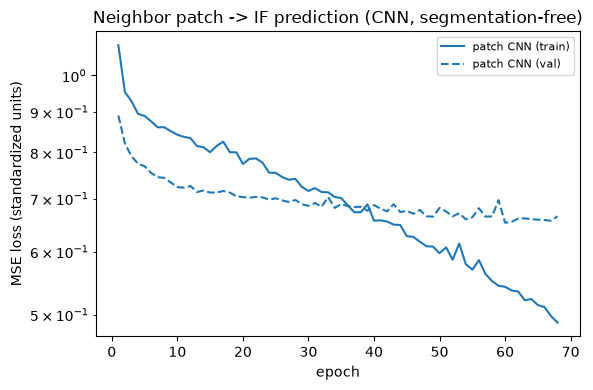

In [4]:
torch.manual_seed(SEED)
cnn_model = NeighborPatchPredictor(
    x_in_channels=len(patch_data['x_cols']),
    neighbor_in_channels=len(patch_data['neighbor_cols']),
    num_outputs=len(patch_data['y_cols']),
)
cnn_history = train_patch_predictor(cnn_model, patch_data['train_ds'], patch_data['val_ds'], desc='patch CNN', lr=1e-4, epochs=1000)
plot_loss_curves({'patch CNN': cnn_history}, title='Neighbor patch -> IF prediction (CNN, segmentation-free)')
plt.show()

,R2,MAE
feature,,
Sox17_mean,0.183672,0.689452


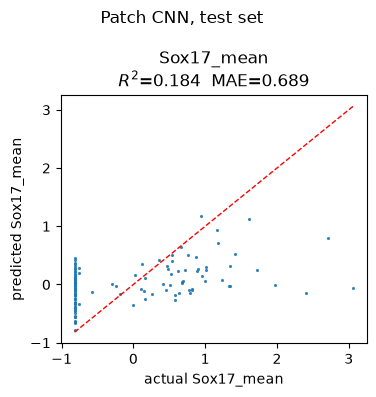

In [5]:
pred_df, true_df = predict_patch_df(
    cnn_model, patch_data['test_ds'], patch_data['y_cols'],  y_scaler=None
    #  y_scaler=patch_data['y_scaler']
)
cnn_r2 = r2_table(true_df, pred_df)
display(cnn_r2)
plot_pred_vs_actual(true_df, pred_df, title='Patch CNN, test set')
plt.show()

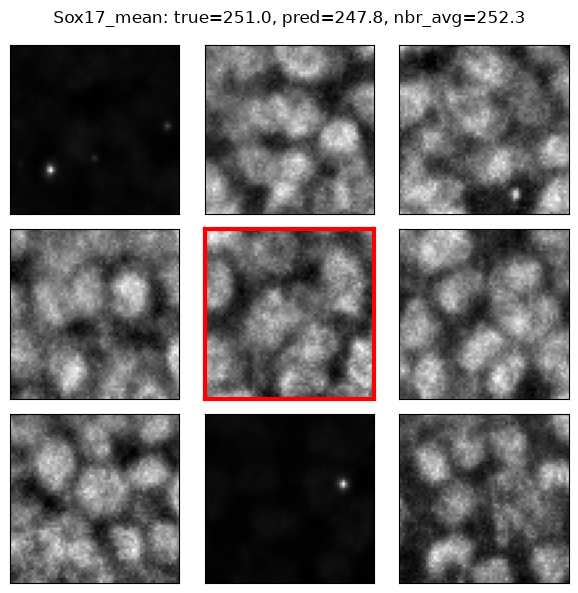

In [6]:
import random

# 3x3 spatial mosaic: the 8 real neighbor patches in their actual grid positions, plus
# the true center patch (red border) -- the model only predicts a scalar, so true/pred
# values go in the suptitle instead of trying to render a "predicted image".
# grid_offsets is in the exact same order build_patch_neighbors enumerates neighbors in
# (dr in (-1,0,1), dc in (-1,0,1), skipping (0,0)), so it lines up with neighbor_idx directly.
grid_offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]

idx = random.randrange(len(patch_data['test_ds']))
test_ds = patch_data['test_ds']
center_i = test_ds.center_indices[idx]
neighbor_indices = test_ds.neighbor_idx[center_i]

x_center, x_neighbors, y_true_scaled = test_ds[idx]
with torch.no_grad():
    y_pred_scaled = cnn_model(x_center.unsqueeze(0), x_neighbors.unsqueeze(0))
y_true = patch_data['y_scaler'].inverse_transform(y_true_scaled.numpy()[None])[0]
y_pred = patch_data['y_scaler'].inverse_transform(y_pred_scaled.numpy())[0]

y_cols = patch_data['y_cols']
patches_list = patch_data['patches']
neighbor_mean = []

for col_i, col in enumerate(y_cols):
    ch = channel_names.index(col.replace('_mean', ''))
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))

    for (dr, dc), n_patch_i in zip(grid_offsets, neighbor_indices):
        p = patches_list[n_patch_i]
        crop = out[ch, p['y0']:p['y1'], p['x0']:p['x1']]
        ax = axes[1 + dr, 1 + dc]
        ax.imshow(crop, cmap='gray')
        ax.set_xticks([]); ax.set_yticks([])

        neighbor_mean.append(crop.mean())

    p_center = patches_list[center_i]
    crop_center = out[ch, p_center['y0']:p_center['y1'], p_center['x0']:p_center['x1']]
    ax = axes[1, 1]
    ax.imshow(crop_center, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(3)

    fig.suptitle(f'{col}: true={y_true[col_i]:.1f}, pred={y_pred[col_i]:.1f}, nbr_avg={np.mean(neighbor_mean):.1f}')
    fig.tight_layout()
    plt.show()

In [7]:
from models.cnn import neighbor_average_df

# Naive, model-free baseline: for every TEST patch, the plain average of its 8
# neighbor patches' own raw mean intensity -- if the model isn't beating this, it
# isn't learning anything a simple average doesn't already capture. Both in SCALED
# units (neighbor_average_df is scaled using y_scaler; predict_patch_df is run with
# y_scaler=None to return scaled values).
pred_df_orig, true_df_orig = predict_patch_df(
    cnn_model, patch_data['test_ds'], patch_data['y_cols'], 
    y_scaler=None
)

test_ds = patch_data['test_ds']
baseline_df = neighbor_average_df(
    out, channel_names, patch_data['patches'], test_ds.neighbor_idx, test_ds.center_indices, patch_data['y_cols'],
    y_scaler=patch_data['y_scaler']
)

model_r2 = r2_table(true_df_orig, pred_df_orig)
baseline_r2 = r2_table(true_df_orig, baseline_df)
comparison = pd.concat({'model': model_r2, 'neighbor avg (baseline)': baseline_r2}, axis=1)
display(comparison)

model           neighbor avg (baseline)          
                  R2       MAE                      R2       MAE
feature                                                         
Sox17_mean  0.183672  0.689452               -0.192336  0.542993

### Comparing against the cell-graph GNN (`features.ipynb`)

If this patch-level R^2 comes out comparably low to the GNN's, that's evidence the
weak neighbor signal is a real biological/imaging-noise finding, not a segmentation
artifact -- two very different "unit of prediction" (fixed grid patch vs. segmented
cell) and neighbor-aggregation mechanisms (CNN encoder vs. distance-weighted graph
conv) agreeing is a much stronger signal than either result alone. If this one comes
out substantially BETTER, that's a real hint the cell segmentation is adding noise on
top of whatever the biology is doing -- worth revisiting `segment.ipynb`'s Cellpose
parameters/filtering before trusting the GNN numbers.